In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load the Advertising dataset directly from URL
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [2]:
# Drop the unnecessary index column
df = df.drop(columns=['Unnamed: 0'])

# 1. First five rows
print("=== First 5 Rows ===")
print(df.head())

# 2. Last five rows
print("\n=== Last 5 Rows ===")
print(df.tail())

# 3. Shape (rows and columns)
print(f"\n=== Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 4. Missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# 5. Descriptive statistics
print("\n=== Descriptive Statistics ===")
print(df.describe())

=== First 5 Rows ===
      TV  radio  newspaper  sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

=== Last 5 Rows ===
        TV  radio  newspaper  sales
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1    9.7
197  177.0    9.3        6.4   12.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   13.4

=== Shape ===
Rows: 200, Columns: 4

=== Missing Values ===
TV           0
radio        0
newspaper    0
sales        0
dtype: int64

=== Descriptive Statistics ===
               TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.9

## Task 1 – Questions & Answers

1. **How many observations are in the dataset?**
   There are 200 observations (rows) in the dataset.

2. **Are there any missing values?**
   No. All four columns (TV, radio, newspaper, sales) have 0 missing values.

3. **What is the average TV advertising budget?**
   The average TV advertising budget is $147.04 (thousand).

4. **What is the average sales value?**
   The average sales value is $14.02 (thousand units).

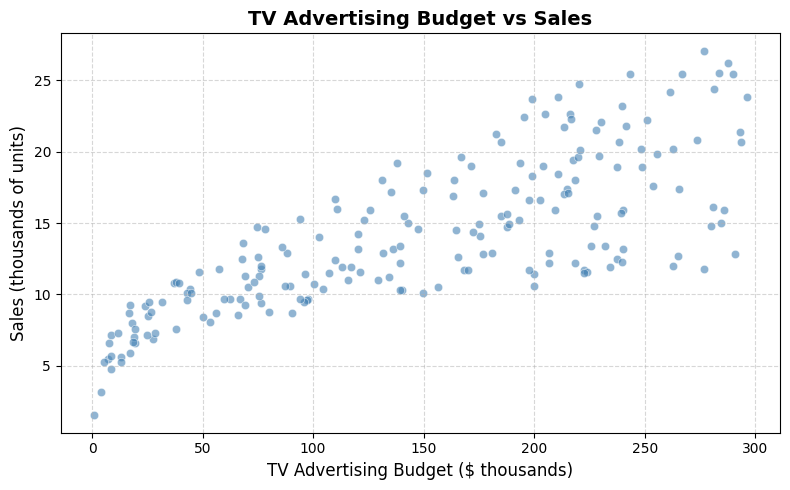

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df['TV'], df['sales'], color='steelblue', alpha=0.6, edgecolors='white', linewidth=0.5)

plt.title('TV Advertising Budget vs Sales', fontsize=14, fontweight='bold')
plt.xlabel('TV Advertising Budget ($ thousands)', fontsize=12)
plt.ylabel('Sales (thousands of units)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Task 2 – Analysis Questions

1. **Is the relationship positive or negative?**
   The relationship is positive. As TV advertising budget increases,
   sales also increase.

2. **Does the relationship appear linear?**
   Yes. The data points follow a roughly straight upward trend,
   suggesting a linear relationship between TV budget and sales.

3. **Are there any unusual observations?**
   There is one notable outlier at the bottom-left, a very low TV
   budget (~$5k) with very low sales (~$1.6k). Overall though, most
   points follow the trend consistently with no extreme anomalies.

In [4]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Select X (TV) and Y (sales)
X = df[['TV']]  # 2D array required by sklearn
y = df['sales']

# Train the model
model = LinearRegression()
model.fit(X, y)

print("Model training complete!")
print(f"Model type: {type(model)}")
print(f"Training samples used: {X.shape[0]}")

Model training complete!
Model type: <class 'sklearn.linear_model._base.LinearRegression'>
Training samples used: 200


In [5]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (Coefficient): {slope:.4f}")
print(f"Intercept:           {intercept:.4f}")

Slope (Coefficient): 0.0475
Intercept:           7.0326


## Task 4 – Model Interpretation

1. **What is the value of the slope?**
   The slope (coefficient) is 0.0475.

2. **What does the slope mean in this business problem?**
   For every $1,000 increase in TV advertising budget, sales increase
   by approximately 0.0475 thousand units (i.e. 47.5 units).
   In other words, every additional $1,000 spent on TV ads generates
   roughly 47 to 48 more product sales.

3. **What is the intercept?**
   The intercept is 7.0326.

4. **Does the intercept make practical sense?**
   It means that even with zero TV advertising spend, the model predicts
   sales of approximately 7,033 units. This could reflect sales driven
   by other channels (radio, newspaper, word of mouth). It is a
   reasonable baseline and makes practical sense in a real business.

In [6]:
# TV budgets to predict
tv_budgets = [[50], [100], [150], [250]]

# Make predictions
predictions = model.predict(tv_budgets)

# Display as a clean table
results = pd.DataFrame({
    'TV Advertising Budget ($thousands)': [50, 100, 150, 250],
    'Predicted Sales (thousands of units)': predictions.round(2)
})

print("=== Sales Predictions ===")
print(results.to_string(index=False))

=== Sales Predictions ===
 TV Advertising Budget ($thousands)  Predicted Sales (thousands of units)
                                 50                                  9.41
                                100                                 11.79
                                150                                 14.16
                                250                                 18.92


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Task 5 – Sales Predictions

| TV Advertising Budget ($thousands) | Predicted Sales (thousands of units) |
|-------------------------------------|---------------------------------------|
| 50                                  | 9.41                                  |
| 100                                 | 11.79                                 |
| 150                                 | 14.16                                 |
| 250                                 | 18.92                                 |

1. **What happens to sales as advertising increases?**
   Sales increase steadily as the TV advertising budget grows.
   Every $50,000 additional spend adds roughly 2,370 units in sales,
   confirming a consistent positive linear relationship.

2. **Do the predictions seem realistic?**
   Yes. The predicted values fall well within the range of actual
   sales in the dataset (min: 1.6k, max: 27.0k), and the steady
   incremental growth aligns with what the scatter plot showed.
   The model produces sensible, business-believable estimates.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


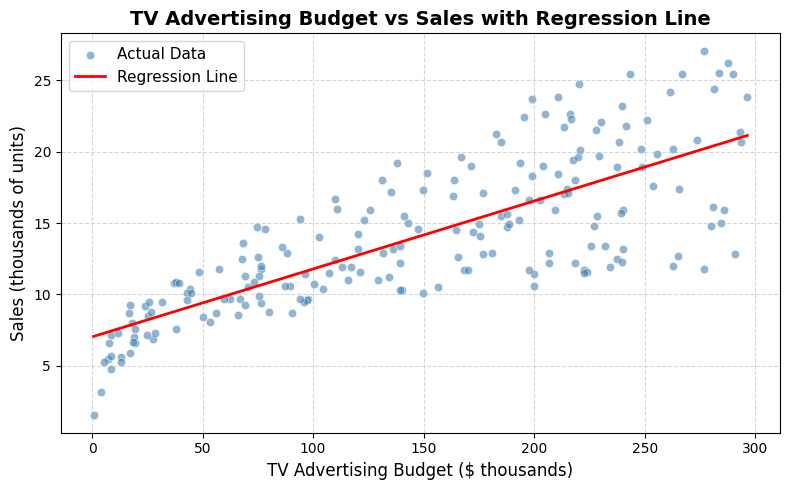

In [8]:
# Generate regression line values
x_line = np.linspace(df['TV'].min(), df['TV'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df['TV'], df['sales'], color='steelblue', alpha=0.6,
            edgecolors='white', linewidth=0.5, label='Actual Data')
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.title('TV Advertising Budget vs Sales with Regression Line',
          fontsize=14, fontweight='bold')
plt.xlabel('TV Advertising Budget ($ thousands)', fontsize=12)
plt.ylabel('Sales (thousands of units)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Task 7 – Findings and Recommendations

### Findings

This analysis examined the relationship between TV advertising budget
and product sales using a Simple Linear Regression model trained on
200 observations.

The scatter plot clearly shows a strong positive linear relationship
between TV advertising spend and sales. As the TV budget increases,
sales rise consistently. The regression line (Sales = 0.0475 × TV + 7.03)
confirms this trend mathematically.

The slope of 0.0475 means that for every $1,000 increase in TV advertising,
sales grow by approximately 47–48 units. The intercept of 7,033 units
represents the baseline sales expected even without TV advertising, likely
driven by other channels. The regression line fits the data well, sitting
centrally through the spread of points across the entire budget range.

### Recommendations

As a marketing manager, I would recommend increasing the TV advertising
budget. The model provides clear evidence that TV spend has a direct and
measurable impact on sales. For example, scaling the budget from $100,000
to $250,000 is predicted to grow sales from approximately 11,790 to 18,920
units, an increase of over 7,000 units.

While there is some scatter around the regression line (suggesting other
factors also influence sales), the overall linear trend is strong and
consistent enough to justify increased TV investment. However, I would
also recommend analysing radio and newspaper channels before making a
final budget decision, to ensure TV delivers the best return compared
to other advertising mediums.

In [9]:
# Train 3 separate models
features = ['TV', 'radio', 'newspaper']
results = {}

for feature in features:
    X_feat = df[[feature]]
    y_feat = df['sales']

    m = LinearRegression()
    m.fit(X_feat, y_feat)

    results[feature] = {
        'slope': m.coef_[0],
        'intercept': m.intercept_,
        'model': m
    }

# Display results
print("=== Model Comparison ===\n")
print(f"{'Channel':<12} {'Slope':>10} {'Intercept':>12}")
print("-" * 36)
for feature, vals in results.items():
    print(f"{feature:<12} {vals['slope']:>10.4f} {vals['intercept']:>12.4f}")

=== Model Comparison ===

Channel           Slope    Intercept
------------------------------------
TV               0.0475       7.0326
radio            0.2025       9.3116
newspaper        0.0547      12.3514


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


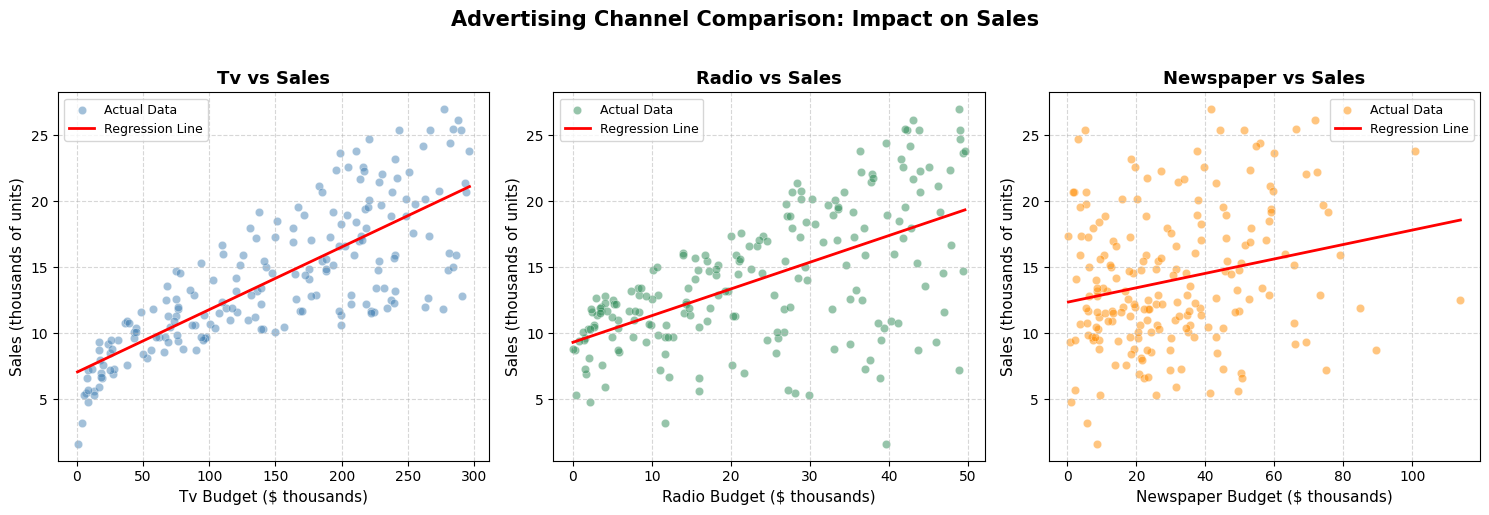

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['steelblue', 'seagreen', 'darkorange']
channels = ['TV', 'radio', 'newspaper']

for i, (feature, color) in enumerate(zip(channels, colors)):
    x_vals = df[feature]
    y_vals = df['sales']

    # Regression line
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    y_line = results[feature]['model'].predict(x_line.reshape(-1, 1))

    axes[i].scatter(x_vals, y_vals, color=color, alpha=0.5,
                    edgecolors='white', linewidth=0.4, label='Actual Data')
    axes[i].plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

    axes[i].set_title(f'{feature.capitalize()} vs Sales',
                      fontsize=13, fontweight='bold')
    axes[i].set_xlabel(f'{feature.capitalize()} Budget ($ thousands)', fontsize=11)
    axes[i].set_ylabel('Sales (thousands of units)', fontsize=11)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Advertising Channel Comparison: Impact on Sales',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Bonus – Advertising Channel Comparison

### Model Results Summary

| Channel   | Slope  | Intercept | Interpretation                          |
|-----------|--------|-----------|------------------------------------------|
| TV        | 0.0475 | 7.0326    | +47.5 units per $1,000 spent            |
| Radio     | 0.2025 | 9.3116    | +202.5 units per $1,000 spent           |
| Newspaper | 0.0547 | 12.3514   | +54.7 units per $1,000 spent            |

### Which channel has the strongest relationship with sales?

Radio has the strongest relationship with sales by a significant margin.
Its slope of 0.2025 means every $1,000 increase in radio advertising
generates approximately 202 additional sales, over 4x more than TV
and nearly 4x more than newspaper.

This is also visible in the plots: the Radio vs Sales scatter plot shows
data points clustering much more tightly around the regression line
compared to TV and Newspaper, indicating a stronger and more consistent
linear relationship.

The newspaper has the weakest relationship; its data points are widely
scattered around the regression line, suggesting newspaper spend has
little reliable impact on sales.

### Recommendation

I would recommend the company prioritise Radio advertising for the
highest return on investment. While TV has a broader budget range and
decent impact, Radio delivers more than 4x the sales uplift per $1,000
spent. Newspaper advertising shows the weakest and least consistent
relationship with sales and should receive the lowest budget priority.